In [11]:
import harmonica as hm

grid = hm.load_oasis_montaj_grid("/workspaces/lineament-ml/data/raw/261_TMI.grd")
print(type(grid))
print(grid)
print(grid.dims, grid.shape)

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray (northing: 1845, easting: 1843)> Size: 27MB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,  0.2070576 , ...,         nan,
                nan,         nan],
       [        nan,         nan,  0.13924433, ..., 52.02843475,
        55.28684998, 58.03604507],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(1845, 1843))
Coordinates:
  * northing  (northing) float64 15kB 7.738e+05 7.738e+05 ... 8.291e+05
  * easting   (easting) float64 15kB 5.552e+05 5.552e+05 ... 6.104e+05 6.104e+05
Attributes: (12/23)
    n_bytes_per_element:  1028
    sign_flag:            2
    shape_e:      

In [12]:
import numpy as np

valid = grid.values[~np.isnan(grid.values)]

print(f"Min:    {valid.min():.2f} nT")
print(f"Max:    {valid.max():.2f} nT")
print(f"Mean:   {valid.mean():.2f} nT")
print(f"Median: {np.median(valid):.2f} nT")
print(f"Std:    {valid.std():.2f} nT")
print(f"Range:  {valid.max() - valid.min():.2f} nT")

Min:    -461.18 nT
Max:    551.12 nT
Mean:   -0.58 nT
Median: 2.17 nT
Std:    45.65 nT
Range:  1012.30 nT


In [13]:
import xml.etree.ElementTree as ET

tree = ET.parse("/workspaces/lineament-ml/data/raw/261_TMI.grd.xml")
root = tree.getroot()

for elem in root.iter():
    if elem.text and elem.text.strip():
        print(f"{elem.tag}: {elem.text.strip()}")

{http://www.geosoft.com/schema/geo}title: 261_TMI
{http://www.geosoft.com/schema/geo}file_format: Geosoft Grid
{http://www.geosoft.com/schema/geo}project_name: c:\users\user\desktop\data window\data.gpf
{http://www.geosoft.com/schema/geo}data_created_by: Tomiwa Akanbi
{http://www.geosoft.com/schema/geo}data_creation_date: 2024-10-21
{http://www.geosoft.com/schema/geo}metadata_created_by: Tomiwa Akanbi
{http://www.geosoft.com/schema/geo}metadata_creation_date: 2024-10-21
{http://www.isotc211.org/2005/gco}DateTime: 2024-10-21T01:35:20
{http://www.isotc211.org/2005/gco}CharacterString: Tomiwa Akanbi
{http://www.isotc211.org/2005/gco}CharacterString: 261_TMI
{http://www.isotc211.org/2005/gco}CharacterString: c:\users\user\desktop\data window\data.gpf
{http://www.isotc211.org/2005/gco}Date: 2024-10-21
{http://www.isotc211.org/2005/gco}CharacterString: Geosoft Grid
{http://www.isotc211.org/2005/gco}CharacterString: Tomiwa Akanbi
{http://www.isotc211.org/2005/gco}Decimal: 3.4995821477855329
{

In [14]:
# Section 3: Preprocessing — final version
# IGRF: already removed by NGSA, skip
# Reprojection: already UTM 31N (EPSG:32631), skip
# Regridding: already regular 30m spacing, skip

# Only remaining step: confirm/clip to the exact sheet 261 boundary
import numpy as np

print("Grid easting range:", grid.easting.values.min(), grid.easting.values.max())
print("Grid northing range:", grid.northing.values.min(), grid.northing.values.max())

# Compare against sheet 261's expected geographic bounds (from XML):
# 3.4996–4.0010 E, 6.9996–7.5008 N (need conversion to UTM 31N meters to compare directly,
# or reproject the bbox corners — recommend using pyproj for this)

Grid easting range: 555180.0 610440.0
Grid northing range: 773820.0 829140.0


In [15]:
import harmonica as hm
import numpy as np

# --- Confirmed inputs from your IGRF calculation ---
# Source: NOAA Magnetic Field calculator, DGRF2005 model, lat 7.25N, lon 3.75E, 2009-01-01
# Convention: declination +East/-West, inclination +Down/-Up
inclination = -11.3996  # degrees
declination = -5.0348   # degrees

# --- Handle NaN edges before any FFT-based operation ---
# grid has NaN padding at edges (irregular flight-line coverage vs rectangular extent)
# FFT-based filters (RTP, derivatives) cannot tolerate any NaNs
nan_mask = np.isnan(grid.values)
grid_filled = grid.fillna(grid.mean())

# --- Reduction to Pole ---
rtp_grid = hm.reduction_to_pole(grid_filled, inclination=inclination, declination=declination)
rtp_grid.values[nan_mask] = np.nan  # restore true NaN edges

# --- Derivatives ---
dx = hm.derivative_easting(grid_filled)
dy = hm.derivative_northing(grid_filled)
dz = hm.derivative_upward(grid_filled)

for arr in (dx, dy, dz):
    arr.values[nan_mask] = np.nan

# --- Analytic Signal Amplitude ---
analytic_signal = np.sqrt(dx**2 + dy**2 + dz**2)
analytic_signal.values[nan_mask] = np.nan

# --- Tilt Derivative ---
tilt_derivative = np.arctan2(dz, np.sqrt(dx**2 + dy**2))
tilt_derivative.values[nan_mask] = np.nan

# --- Horizontal Gradient Magnitude ---
horizontal_gradient = np.sqrt(dx**2 + dy**2)
horizontal_gradient.values[nan_mask] = np.nan

# --- Stack into feature array for the ML step ---
feature_stack = np.stack([
    grid.values,
    rtp_grid.values,
    analytic_signal.values,
    tilt_derivative.values,
    horizontal_gradient.values,
], axis=-1)

print("Feature stack shape:", feature_stack.shape)  # expect (1845, 1843, 5)
print("NaN count in stack:", np.isnan(feature_stack).sum())

/workspaces/lineament-ml/venv/lib/python3.12/site-packages/harmonica/filters/_fft.py:48: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  grid = grid.drop(bad_coords)
/workspaces/lineament-ml/venv/lib/python3.12/site-packages/xrft/xrft.py:455: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  daft = daft.drop([d for d in dim if d in daft.coords])
/workspaces/lineament-ml/venv/lib/python3.12/site-packages/xrft/xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)
/workspaces/lineament-ml/venv/lib/python3.12/site-packages/xrft/xrft.py:671: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  da = da.drop([d for d in dim if d in da.coords])
/workspaces/lineament-ml/venv/lib/python3.12/site-packages/harmonica/filters/_fft.py:4

Feature stack shape: (1845, 1843, 5)
NaN count in stack: 602915


In [16]:
def threshold_filter(arr, percentile=90):
    valid = arr[~np.isnan(arr)]
    threshold = np.percentile(valid, percentile)
    return arr > threshold

# Use the three filters most sensitive to edges/contacts: ASA, TDR, HGM
asa_flag = threshold_filter(analytic_signal.values)
tdr_flag = threshold_filter(np.abs(tilt_derivative.values))
hgm_flag = threshold_filter(horizontal_gradient.values)

# Consensus: pixel counts as a lineament label only if flagged by >= 2 of 3
agreement_count = (
    asa_flag.astype(int) + tdr_flag.astype(int) + hgm_flag.astype(int)
)
consensus_label = agreement_count >= 2

print("Total pixels:", consensus_label.size)
print("Labeled as lineament:", consensus_label.sum())
print("Percent labeled:", 100 * consensus_label.sum() / consensus_label.size)

Total pixels: 3400335
Labeled as lineament: 269943
Percent labeled: 7.938717802804724


In [17]:
for p in (85, 90, 95):
    asa_flag = threshold_filter(analytic_signal.values, percentile=p)
    tdr_flag = threshold_filter(np.abs(tilt_derivative.values), percentile=p)
    hgm_flag = threshold_filter(horizontal_gradient.values, percentile=p)
    agreement = asa_flag.astype(int) + tdr_flag.astype(int) + hgm_flag.astype(int)
    label = agreement >= 2
    print(f"Percentile {p}: {label.sum()} pixels labeled ({100*label.sum()/label.size:.2f}%)")

Percentile 85: 439547 pixels labeled (12.93%)


Percentile 90: 269943 pixels labeled (7.94%)
Percentile 95: 118364 pixels labeled (3.48%)


In [18]:
np.save("data/processed/feature_stack.npy", feature_stack)
np.save("data/processed/consensus_label.npy", consensus_label)
np.save("data/processed/rtp_grid_values.npy", rtp_grid.values)
print("Saved.")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/feature_stack.npy'

In [ ]:
feature_stack_clean = np.stack([
    grid.values,
    rtp_grid.values,
], axis=-1)

n_rows, n_cols = consensus_label.shape
row_idx, col_idx = np.meshgrid(np.arange(n_rows), np.arange(n_cols), indexing="ij")

X_full = feature_stack_clean.reshape(-1, feature_stack_clean.shape[-1])
y_full = consensus_label.flatten()
row_full = row_idx.flatten()
col_full = col_idx.flatten()

valid_rows = ~np.isnan(X_full).any(axis=1)
X = X_full[valid_rows]
y = y_full[valid_rows]
row_v = row_full[valid_rows]
col_v = col_full[valid_rows]

# Spatial block split: eastern 30% of grid held out as test, avoids
# random-split leakage between neighboring pixels
col_threshold = np.percentile(col_v, 70)
train_mask = col_v < col_threshold
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train pixels:", X_train.shape[0], "| Test pixels:", X_test.shape[0])
print("Train lineament fraction:", y_train.mean(), "| Test lineament fraction:", y_test.mean())

Tiny fit took: 0.19884467124938965 seconds


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import time

t0 = time.time()
with joblib.parallel_backend("threading"):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        n_jobs=2,
        random_state=42,
    )
    rf.fit(X_train, y_train)

print("RF fit took:", time.time() - t0, "seconds")

print("\nRandom Forest (TMI + RTP only, spatial block split)")
rf_preds = rf.predict(X_test)
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

In [ ]:
from sklearn.svm import SVC
from sklearn.utils import resample
import time

X_train_svm, y_train_svm = resample(
    X_train, y_train, n_samples=50000, stratify=y_train, random_state=42
)

t0 = time.time()
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_svm, y_train_svm)
print("SVM fit took:", time.time() - t0, "seconds")

print("\nSVM (RBF, TMI + RTP only, spatial block split, 50k subsample)")
svm_preds = svm.predict(X_test)
print(classification_report(y_test, svm_preds))
print(confusion_matrix(y_test, svm_preds))

In [2]:
import os
os.makedirs("/workspaces/lineament-ml/outputs/figures", exist_ok=True)

plt.savefig("/workspaces/lineament-ml/outputs/figures/figure1_location_map.png", dpi=300, bbox_inches="tight")
plt.savefig("/workspaces/lineament-ml/outputs/figures/figure1_location_map.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

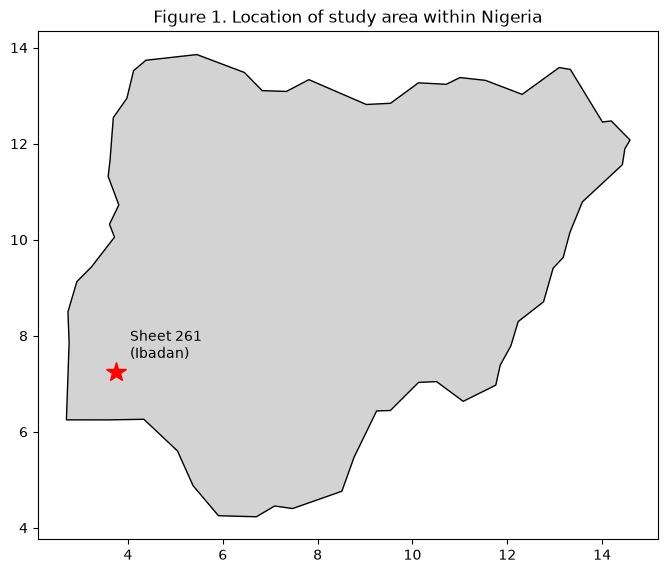

In [4]:
import os
os.makedirs("/workspaces/lineament-ml/outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 8))
nigeria.plot(ax=ax, color="lightgrey", edgecolor="black")
ax.plot(3.75, 7.25, marker="*", color="red", markersize=15, zorder=5)
ax.annotate("Sheet 261\n(Ibadan)", (3.75, 7.25), textcoords="offset points", xytext=(10, 10))
ax.set_title("Figure 1. Location of study area within Nigeria")

plt.savefig("/workspaces/lineament-ml/outputs/figures/figure1_location_map.png", dpi=300, bbox_inches="tight")
plt.savefig("/workspaces/lineament-ml/outputs/figures/figure1_location_map.pdf", bbox_inches="tight")
plt.show()